In [1]:

import os
import re
import math
import warnings
import h5py
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

import scipy.integrate as si

# Compatibility patch for older lifelines with newer SciPy
if not hasattr(si, "trapz"):
    from scipy.integrate import trapezoid
    si.trapz = trapezoid

if not hasattr(si, "cumtrapz"):
    from scipy.integrate import cumulative_trapezoid
    si.cumtrapz = cumulative_trapezoid

if not hasattr(si, "simps"):
    from scipy.integrate import simpson
    si.simps = simpson


from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = False

In [2]:

# ============================================================
# USER CONFIG
# ============================================================

EMB_PATH = "/proj/berzelius-2025-315/users/x_dilwi/AI-supported-Survival-Prediction-from-Multichannel-Microscopy-Images-of-Cancer-Tissue/KRONOS/bomi2_kronos/embeddings_patch"
NAMES_PATH = None 
CLINICAL_CSV = "/proj/berzelius-2025-315/users/x_dilwi/bomi2_image_level_with_survival.csv"
FOLDS_DIR = "/proj/berzelius-2025-315/users/x_dilwi/BOMI2_folds"

OUTDIR = Path("/proj/berzelius-2025-315/users/x_dilwi/AI-supported-Survival-Prediction-from-Multichannel-Microscopy-Images-of-Cancer-Tissue//KRONOS/bomi2_kronos/survival_KRONOS_results")
OUTDIR.mkdir(parents=True, exist_ok=True)

PATIENT_COL = "patient_id"
TIME_COL = "time"
EVENT_COL = "event"
IMAGE_COL = "image_name"
IMAGE_PATH_COL = "image_path"

POOL_LEVEL = "patient"  # "patch", "core", "patient"

ALPHAS = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
USE_PCA = False
PCA_DIM = 50

EVAL_YEARS = [1, 2, 3, 4, 5]
DAYS_PER_YEAR = 365.25

RISK_GROUPING = "median"   # "median" or "tertiles"
SELECTED_FOLD_FOR_DETAILED_PLOTS = 0

PATCH_SUFFIX_PATTERNS = [
    r"_patch_\d+$",
    r"_patch\d+$",
    r"_p\d+$",
    r"_r\d+_c\d+$",
    r"_row\d+_col\d+$",
    r"_x\d+_y\d+$",
    r"_\d+_\d+$",
]

In [3]:

# ============================================================
# Helpers
# ============================================================



from pathlib import Path
import re

def decode_if_bytes(x):
    if isinstance(x, bytes):
        return x.decode("utf-8")
    return str(x)

def norm_name(x):
    s = str(x).strip()
    s = Path(s).name
    s = re.sub(r"\.tiff?$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\.npy$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\.npz$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"_core$", "", s, flags=re.IGNORECASE)   # <-- add this
    
    return s

def canon_pid(x):
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

def list_fold_files(folds_dir=FOLDS_DIR):
    folds_dir = Path(folds_dir)
    found = {}

    for i in range(10):
        found[i] = {}

        candidates = {
            "train": [
                f"split_{i}_train.csv",
                f"fold{i}_train.csv",
                f"train_fold_{i}.csv",
                f"train_{i}.csv",
            ],
            "val": [
                f"split_{i}_val.csv",
                f"split_{i}_valid.csv",
                f"split_{i}_validation.csv",
                f"fold{i}_val.csv",
                f"val_fold_{i}.csv",
                f"val_{i}.csv",
            ],
            "test": [
                f"split_{i}_test.csv",
                f"fold{i}_test.csv",
                f"test_fold_{i}.csv",
                f"test_{i}.csv",
            ],
        }

        for split, pats in candidates.items():
            hit = None
            for p in pats:
                candidate = folds_dir / p
                if candidate.exists():
                    hit = candidate
                    break
            found[i][split] = hit

    return found

def get_fold_paths(folds_dir, fold_idx):
    folds_dir = Path(folds_dir)

    train_csv = folds_dir / f"split_{fold_idx}_train.csv"
    test_csv  = folds_dir / f"split_{fold_idx}_test.csv"

    val_candidates = [
        folds_dir / f"split_{fold_idx}_val.csv",
        folds_dir / f"split_{fold_idx}_valid.csv",
        folds_dir / f"split_{fold_idx}_validation.csv",
    ]

    val_csv = None
    for p in val_candidates:
        if p.exists():
            val_csv = p
            break

    missing = []
    if not train_csv.exists():
        missing.append(str(train_csv))
    if val_csv is None:
        missing.append(f"split_{fold_idx}_[val|valid|validation].csv")
    if not test_csv.exists():
        missing.append(str(test_csv))

    if missing:
        return None, None, None, missing

    return train_csv, val_csv, test_csv, []

def strip_patch_suffix(name):
    s = norm_name(name)
    changed = True
    while changed:
        old = s
        for pat in PATCH_SUFFIX_PATTERNS:
            s = re.sub(pat, "", s, flags=re.IGNORECASE)
        changed = (s != old)
    return s

def to_structured_surv(df, time_col=TIME_COL, event_col=EVENT_COL):
    df = df.copy()
    df[event_col] = df[event_col].astype(bool)
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
    return Surv.from_dataframe(event_col, time_col, df)

def neg_partial_log_likelihood(risk_scores, times, events):
    risk_scores = np.asarray(risk_scores, dtype=float)
    times = np.asarray(times, dtype=float)
    events = np.asarray(events, dtype=int)

    order = np.argsort(-times)
    risk_scores = risk_scores[order]
    times = times[order]
    events = events[order]

    exp_risk = np.exp(risk_scores - np.max(risk_scores))
    cum_sum = np.cumsum(exp_risk)

    nll = 0.0
    n_events = 0

    i = 0
    n = len(times)
    while i < n:
        t = times[i]
        j = i
        while j < n and times[j] == t:
            j += 1

        idx = slice(i, j)
        d = events[idx].sum()

        if d > 0:
            event_idx = np.where(events[idx] == 1)[0] + i
            nll -= risk_scores[event_idx].sum()
            nll += d * np.log(cum_sum[j - 1])
            n_events += d

        i = j

    return float(nll / max(n_events, 1))

def valid_eval_times(train_y, test_y, desired_times_days):
    desired_times_days = np.asarray(desired_times_days, dtype=float)

    train_event_times = train_y[train_y["event"]]["time"]
    test_times = test_y["time"]

    if len(train_event_times) == 0 or len(test_times) == 0:
        return np.array([])

    lower = max(np.min(train_event_times), np.min(test_times))
    upper = min(np.max(train_event_times), np.max(test_times))

    times = desired_times_days[(desired_times_days > lower) & (desired_times_days < upper)]
    return np.unique(times)

def assign_risk_groups(scores, mode="median"):
    scores = np.asarray(scores, dtype=float)

    if mode == "median":
        thr = np.nanmedian(scores)
        groups = np.where(scores > thr, "High risk", "Low risk")
        return groups, {"median_threshold": float(thr)}

    elif mode == "tertiles":
        q1, q2 = np.nanquantile(scores, [1/3, 2/3])
        groups = np.where(scores <= q1, "Low risk",
                 np.where(scores <= q2, "Intermediate risk", "High risk"))
        return groups, {"q1": float(q1), "q2": float(q2)}

    else:
        raise ValueError(f"Unknown grouping mode: {mode}")

def km_plot_with_pvalue(df, risk_col, title="", show_median=True, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    kmf = KaplanMeierFitter()
    groups = df[risk_col].dropna().unique().tolist()

    if len(groups) == 2:
        g1, g2 = groups
        d1 = df[df[risk_col] == g1]
        d2 = df[df[risk_col] == g2]

        res = logrank_test(
            d1[TIME_COL], d2[TIME_COL],
            event_observed_A=d1[EVENT_COL],
            event_observed_B=d2[EVENT_COL]
        )
        pval = res.p_value
    else:
        res = multivariate_logrank_test(
            df[TIME_COL], df[risk_col], df[EVENT_COL]
        )
        pval = res.p_value

    for g in sorted(groups):
        sub = df[df[risk_col] == g]
        kmf.fit(sub[TIME_COL], event_observed=sub[EVENT_COL], label=f"{g} (n={len(sub)})")
        kmf.plot_survival_function(ax=ax, ci_show=False)

        if show_median:
            med = kmf.median_survival_time_
            if np.isfinite(med):
                ax.axhline(0.5, linestyle="--", linewidth=1, alpha=0.4, color="gray")
                ax.axvline(med, linestyle="--", linewidth=1, alpha=0.4)

    ax.set_title(f"{title}\nlog-rank p = {pval:.4g}")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Survival probability")
    return ax, pval

def load_embeddings(emb_path=EMB_PATH, names_path=NAMES_PATH):
    """
    Load KRONOS embedding .h5 files and pool patch_embeddings to one vector per image/core.
    This keeps the rest of the survival pipeline unchanged.

    Expected per-file datasets:
      - patch_embeddings: (n_patches, emb_dim)
    Expected attrs:
      - image_name
      - patient_id (optional, not used here)
    """
    emb_dir = Path(emb_path)
    h5_files = sorted(emb_dir.glob("*_embeddings.h5"))

    if len(h5_files) == 0:
        raise ValueError(f"No embedding .h5 files found in: {emb_dir}")

    vecs = []
    rows = []

    for h5_path in h5_files:
        with h5py.File(h5_path, "r") as f:
            if "patch_embeddings" not in f:
                raise KeyError(f"'patch_embeddings' not found in {h5_path}")

            patch_emb = f["patch_embeddings"][:]   # shape: (num_patches, emb_dim)

            if patch_emb.ndim != 2:
                raise ValueError(
                    f"Expected patch_embeddings to have shape (num_patches, emb_dim), "
                    f"got {patch_emb.shape} in {h5_path}"
                )

            # pool all patches of one image/core into one image-level embedding
            pooled = patch_emb.mean(axis=0).astype(np.float32)

            image_name = f.attrs.get("image_name", None)
            if image_name is None:
                # fallback from filename
                image_name = h5_path.name.replace("_embeddings.h5", ".tif")

            image_name = decode_if_bytes(image_name)

        vecs.append(pooled)
        rows.append({
            "idx": len(vecs) - 1,
            "image_name_raw": image_name,
        })

    emb = np.vstack(vecs).astype(np.float32)
    df = pd.DataFrame(rows)

    # exact normalized image/core name
    df["merge_key"] = df["image_name_raw"].map(norm_name)

    print(f"Loaded KRONOS image-level embeddings: {emb.shape}")
    print(f"Unique merge keys in embeddings: {df['merge_key'].nunique()}")

    return emb, df

def load_clinical(clinical_csv=CLINICAL_CSV):
    clin = pd.read_csv(clinical_csv).copy()

    required = [PATIENT_COL, TIME_COL, EVENT_COL]
    for c in required:
        if c not in clin.columns:
            raise KeyError(f"Missing required clinical column: {c}")

    if IMAGE_COL in clin.columns:
        raw_image = clin[IMAGE_COL].astype(str)
    elif IMAGE_PATH_COL in clin.columns:
        raw_image = clin[IMAGE_PATH_COL].astype(str)
    else:
        raise KeyError(f"Need either {IMAGE_COL} or {IMAGE_PATH_COL} in clinical CSV")

    # exact normalized image/core key
    clin["merge_key"] = raw_image.map(norm_name)

    clin[PATIENT_COL] = clin[PATIENT_COL].astype(str)
    clin[TIME_COL] = pd.to_numeric(clin[TIME_COL], errors="coerce")
    clin[EVENT_COL] = pd.to_numeric(clin[EVENT_COL], errors="coerce").fillna(0).astype(int)

    clin = clin[clin[TIME_COL] > 0].copy()
    clin = clin.dropna(subset=[PATIENT_COL, TIME_COL, EVENT_COL, "merge_key"]).reset_index(drop=True)

    print(f"Clinical rows after filtering: {len(clin)}")
    print(f"Unique merge keys in clinical: {clin['merge_key'].nunique()}")

    return clin

def merge_embeddings_with_clinical(emb, emb_df, clin_df):
    merged = emb_df.merge(
        clin_df,
        on="merge_key",
        how="inner",
        suffixes=("_emb", "_clin")
    ).copy()

    print(f"Matched rows: {len(merged)} / {len(emb_df)} ({100 * len(merged) / max(1, len(emb_df)):.1f}%)")

    if len(merged) == 0:
        emb_keys = set(emb_df["merge_key"].astype(str))
        clin_keys = set(clin_df["merge_key"].astype(str))

        print("n embedding keys:", len(emb_keys))
        print("n clinical keys:", len(clin_keys))
        print("n overlap:", len(emb_keys & clin_keys))

        print("\nExample embedding keys:")
        for x in list(sorted(emb_keys))[:10]:
            print(repr(x))

        print("\nExample clinical keys:")
        for x in list(sorted(clin_keys))[:10]:
            print(repr(x))

        raise ValueError("No matches found between embeddings and clinical data.")

    return merged

def aggregate_level(emb, merged_df):
    rows = []
    vecs = []

    for pid, sub in merged_df.groupby(PATIENT_COL):
        Xg = emb[sub["idx"].values].mean(axis=0)
        vecs.append(Xg)

        row = sub.iloc[0].copy()
        row[PATIENT_COL] = str(pid)
        row[TIME_COL] = float(sub[TIME_COL].iloc[0])
        row[EVENT_COL] = int(sub[EVENT_COL].iloc[0])
        row["n_cores_aggregated"] = len(sub)
        rows.append(row)

    if len(vecs) == 0:
        raise ValueError("No patient groups were formed.")

    X = np.vstack(vecs).astype(np.float32)
    X = normalize(X)

    meta = pd.DataFrame(rows).reset_index(drop=True)
    return X, meta


def subset_by_ids(X_all, patient_meta, ids):
    ids = set(pd.Series(ids).astype(str))
    meta = patient_meta.copy()
    meta[PATIENT_COL] = meta[PATIENT_COL].astype(str)

    keep = meta[PATIENT_COL].isin(ids).values
    X = X_all[keep]
    meta = meta.loc[keep].reset_index(drop=True)

    return X, meta

def extract_patient_ids_from_fold_csv(csv_path):
    df = pd.read_csv(csv_path).copy()

    candidate_cols = ["ID", "patient_id", "PatientID", "patient", "pid"]

    id_col = None
    for c in candidate_cols:
        if c in df.columns:
            id_col = c
            break

    if id_col is None:
        raise KeyError(
            f"Could not find a patient ID column in {csv_path}. "
            f"Columns found: {df.columns.tolist()}"
        )

    ids = df[id_col].dropna().map(canon_pid).astype(str).unique().tolist()
    return sorted(ids)

def prepare_patient_level_dataset():
    emb, emb_df = load_embeddings()
    clin = load_clinical()
    merged = merge_embeddings_with_clinical(emb, emb_df, clin)

    X, patient_meta = aggregate_level(emb, merged)
    patient_meta[PATIENT_COL] = patient_meta[PATIENT_COL].astype(str)

    return X, patient_meta, merged

def fit_one_cox_model(X_train, y_train, alpha, use_pca=USE_PCA, pca_dim=PCA_DIM):
    steps = [("scaler", StandardScaler())]

    if use_pca:
        pca_dim_use = min(pca_dim, X_train.shape[0] - 1, X_train.shape[1])
        if pca_dim_use >= 1:
            steps.append(("pca", PCA(n_components=pca_dim_use, random_state=42)))

    steps.append(("coxph", CoxPHSurvivalAnalysis(alpha=alpha)))
    pipe = Pipeline(steps)
    pipe.fit(X_train, y_train)
    return pipe

def cindex_from_model(model, X, y):
    risk = model.predict(X)
    c = concordance_index_censored(y["event"], y["time"], risk)[0]
    return float(c), risk

def evaluate_fold(model, X_train, y_train, X_val, y_val, X_test, y_test):
    c_train, risk_train = cindex_from_model(model, X_train, y_train)
    c_val, risk_val = cindex_from_model(model, X_val, y_val)
    c_test, risk_test = cindex_from_model(model, X_test, y_test)

    desired_times_days = np.array(EVAL_YEARS) * DAYS_PER_YEAR
    times = valid_eval_times(y_train, y_test, desired_times_days)

    auc_times = np.array([])
    auc_vals = np.array([])
    mean_auc = np.nan
    if len(times) > 0:
        auc_vals, mean_auc = cumulative_dynamic_auc(y_train, y_test, risk_test, times)
        auc_times = times

    metrics = {
        "cindex_train": c_train,
        "cindex_val": c_val,
        "cindex_test": c_test,
        "npll_train": neg_partial_log_likelihood(risk_train, y_train["time"], y_train["event"]),
        "npll_val": neg_partial_log_likelihood(risk_val, y_val["time"], y_val["event"]),
        "npll_test": neg_partial_log_likelihood(risk_test, y_test["time"], y_test["event"]),
        "auc_times": auc_times,
        "auc_vals": auc_vals,
        "mean_auc_test": float(mean_auc) if np.isfinite(mean_auc) else np.nan,
        "risk_train": risk_train,
        "risk_val": risk_val,
        "risk_test": risk_test,
    }
    return metrics

In [7]:
from pathlib import Path
import h5py

emb_dir = Path("/proj/berzelius-2025-315/users/x_dilwi/AI-supported-Survival-Prediction-from-Multichannel-Microscopy-Images-of-Cancer-Tissue/KRONOS/bomi2_kronos/embeddings_patch")

bad_files = []
good_files = []

for h5_path in sorted(emb_dir.glob("*_embeddings.h5")):
    try:
        with h5py.File(h5_path, "r") as f:
            _ = list(f.keys())  # force read header
        good_files.append(h5_path)
    except Exception as e:
        bad_files.append((h5_path, str(e)))

print("Good files:", len(good_files))
print("Bad files:", len(bad_files))

for p, e in bad_files[:20]:
    print(p.name, "->", e)

Good files: 542
Bad files: 0


In [6]:
emb, emb_df = load_embeddings()
clin = load_clinical()

print("emb shape:", emb.shape)
print("emb_df rows:", len(emb_df))
print("clinical rows after filtering:", len(clin))

merged = merge_embeddings_with_clinical(emb, emb_df, clin)
print("merged rows:", len(merged))

display(emb_df.head())
display(clin.head())
display(merged.head())

Loaded KRONOS image-level embeddings: (542, 384)
Unique merge keys in embeddings: 542
Clinical rows after filtering: 541
Unique merge keys in clinical: 541
emb shape: (542, 384)
emb_df rows: 542
clinical rows after filtering: 541
Matched rows: 541 / 542 (99.8%)
merged rows: 541


,idx,image_name_raw,merge_key
0,0,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...","BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component..."
1,1,"BOMI2_TIL_1_Core[1,1,C]_[8663,35138]_component...","BOMI2_TIL_1_Core[1,1,C]_[8663,35138]_component..."
2,2,"BOMI2_TIL_1_Core[1,1,D]_[10473,35233]_componen...","BOMI2_TIL_1_Core[1,1,D]_[10473,35233]_componen..."
3,3,"BOMI2_TIL_1_Core[1,1,E]_[12330,35106]_componen...","BOMI2_TIL_1_Core[1,1,E]_[12330,35106]_componen..."
4,4,"BOMI2_TIL_1_Core[1,1,G]_[15997,34963]_componen...","BOMI2_TIL_1_Core[1,1,G]_[15997,34963]_componen..."


,image_path,image_name,sample_name,row,col,patient_id_raw,patient_id,region_area_mm2,sample_region,cohort,...,Age,Sex,Smoking,Stage (7th ed.),Performance status (WHO),Follow-up (days),Dead/Alive,time,event,merge_key
0,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...","BOMI2_TIL_1_[1,A]",1,A,Lung # 479,479,0.107100,T,Lung,...,71.0,Female,Current smoker,Ib,1.0,4294.0,Alive,4294.0,0,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component..."
1,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,C]_[8663,35138]_component...","BOMI2_TIL_1_[1,C]",1,C,Lung # 561,561,0.606719,T,Lung,...,62.0,Female,Current smoker,Ia,1.0,3977.0,Alive,3977.0,0,"BOMI2_TIL_1_Core[1,1,C]_[8663,35138]_component..."
2,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,D]_[10473,35233]_componen...","BOMI2_TIL_1_[1,D]",1,D,Lung # 766,766,0.278944,T,Lung,...,59.0,Male,Ex-smoker,Ib,1.0,3227.0,Alive,3227.0,0,"BOMI2_TIL_1_Core[1,1,D]_[10473,35233]_componen..."
3,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,E]_[12330,35106]_componen...","BOMI2_TIL_1_[1,E]",1,E,Lung # 743,743,0.422967,T,Lung,...,64.0,Female,Never-smoker,Ia,0.0,3266.0,Alive,3266.0,0,"BOMI2_TIL_1_Core[1,1,E]_[12330,35106]_componen..."
4,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,G]_[15997,34963]_componen...","BOMI2_TIL_1_[1,G]",1,G,Lung # 779,779,0.389901,T,Lung,...,75.0,Female,Current smoker,Ia,0.0,2666.0,Dead,2666.0,1,"BOMI2_TIL_1_Core[1,1,G]_[15997,34963]_componen..."


,idx,image_name_raw,merge_key,image_path,image_name,sample_name,row,col,patient_id_raw,patient_id,...,Histology,Age,Sex,Smoking,Stage (7th ed.),Performance status (WHO),Follow-up (days),Dead/Alive,time,event
0,0,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...","BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...",/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...","BOMI2_TIL_1_[1,A]",1,A,Lung # 479,479,...,Squamous cell carcinoma,71.0,Female,Current smoker,Ib,1.0,4294.0,Alive,4294.0,0
1,1,"BOMI2_TIL_1_Core[1,1,C]_[8663,35138]_component...","BOMI2_TIL_1_Core[1,1,C]_[8663,35138]_component...",/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,C]_[8663,35138]_component...","BOMI2_TIL_1_[1,C]",1,C,Lung # 561,561,...,Adenocarcinoma,62.0,Female,Current smoker,Ia,1.0,3977.0,Alive,3977.0,0
2,2,"BOMI2_TIL_1_Core[1,1,D]_[10473,35233]_componen...","BOMI2_TIL_1_Core[1,1,D]_[10473,35233]_componen...",/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,D]_[10473,35233]_componen...","BOMI2_TIL_1_[1,D]",1,D,Lung # 766,766,...,Adenocarcinoma,59.0,Male,Ex-smoker,Ib,1.0,3227.0,Alive,3227.0,0
3,3,"BOMI2_TIL_1_Core[1,1,E]_[12330,35106]_componen...","BOMI2_TIL_1_Core[1,1,E]_[12330,35106]_componen...",/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,E]_[12330,35106]_componen...","BOMI2_TIL_1_[1,E]",1,E,Lung # 743,743,...,Adenocarcinoma,64.0,Female,Never-smoker,Ia,0.0,3266.0,Alive,3266.0,0
4,4,"BOMI2_TIL_1_Core[1,1,G]_[15997,34963]_componen...","BOMI2_TIL_1_Core[1,1,G]_[15997,34963]_componen...",/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_Core[1,1,G]_[15997,34963]_componen...","BOMI2_TIL_1_[1,G]",1,G,Lung # 779,779,...,Squamous cell carcinoma,75.0,Female,Current smoker,Ia,0.0,2666.0,Dead,2666.0,1


In [8]:

# ============================================================
# Prepare data
# ============================================================

X_all, patient_meta, merged_patch_meta = prepare_patient_level_dataset()

print("Patient-level matrix shape:", X_all.shape)
display(patient_meta[[PATIENT_COL, TIME_COL, EVENT_COL]].head())

Loaded KRONOS image-level embeddings: (542, 384)
Unique merge keys in embeddings: 542
Clinical rows after filtering: 541
Unique merge keys in clinical: 541
Matched rows: 541 / 542 (99.8%)
Patient-level matrix shape: (297, 384)


,patient_id,time,event
0,400,1233.0,1
1,401,1888.0,1
2,402,4656.0,0
3,405,3523.0,1
4,406,4491.0,0


In [9]:
X_all, patient_meta, merged = prepare_patient_level_dataset()
patient_meta[PATIENT_COL] = patient_meta[PATIENT_COL].map(canon_pid).astype(str)

fold_files = list_fold_files()

for i in range(10):
    print(i, {k: (v.name if v is not None else None) for k, v in fold_files[i].items()})

Loaded KRONOS image-level embeddings: (542, 384)
Unique merge keys in embeddings: 542
Clinical rows after filtering: 541
Unique merge keys in clinical: 541
Matched rows: 541 / 542 (99.8%)
0 {'train': 'split_0_train.csv', 'val': 'split_0_val.csv', 'test': 'split_0_test.csv'}
1 {'train': 'split_1_train.csv', 'val': 'split_1_val.csv', 'test': 'split_1_test.csv'}
2 {'train': 'split_2_train.csv', 'val': 'split_2_val.csv', 'test': 'split_2_test.csv'}
3 {'train': 'split_3_train.csv', 'val': 'split_3_val.csv', 'test': 'split_3_test.csv'}
4 {'train': 'split_4_train.csv', 'val': 'split_4_val.csv', 'test': 'split_4_test.csv'}
5 {'train': 'split_5_train.csv', 'val': 'split_5_val.csv', 'test': 'split_5_test.csv'}
6 {'train': 'split_6_train.csv', 'val': 'split_6_val.csv', 'test': 'split_6_test.csv'}
7 {'train': 'split_7_train.csv', 'val': 'split_7_val.csv', 'test': 'split_7_test.csv'}
8 {'train': 'split_8_train.csv', 'val': 'split_8_val.csv', 'test': 'split_8_test.csv'}
9 {'train': 'split_9_train.cs

In [10]:
# ============================================================
# Cross-validation using predetermined train / val / test splits
# ============================================================

all_fold_rows = []
all_tuning_rows = []
oof_test_rows = []

patient_index = patient_meta[PATIENT_COL].map(canon_pid).astype(str)

for fold_idx in range(10):
    paths = fold_files[fold_idx]

    if any(paths[s] is None for s in ["train", "val", "test"]):
        print(f"Skipping fold {fold_idx}: missing one or more split files")
        print({k: (v.name if v is not None else None) for k, v in paths.items()})
        continue

    train_ids = extract_patient_ids_from_fold_csv(paths["train"])
    val_ids   = extract_patient_ids_from_fold_csv(paths["val"])
    test_ids  = extract_patient_ids_from_fold_csv(paths["test"])

    train_ids = set(map(str, train_ids))
    val_ids   = set(map(str, val_ids))
    test_ids  = set(map(str, test_ids))

    tr_mask = patient_index.isin(train_ids).values
    va_mask = patient_index.isin(val_ids).values
    te_mask = patient_index.isin(test_ids).values

    X_train = X_all[tr_mask]
    X_val   = X_all[va_mask]
    X_test  = X_all[te_mask]

    meta_train = patient_meta.loc[tr_mask].reset_index(drop=True)
    meta_val   = patient_meta.loc[va_mask].reset_index(drop=True)
    meta_test  = patient_meta.loc[te_mask].reset_index(drop=True)

    print(f"\nFold {fold_idx}")
    print("files:",
          paths["train"].name if paths["train"] else None,
          paths["val"].name if paths["val"] else None,
          paths["test"].name if paths["test"] else None)
    print("ID counts:", len(train_ids), len(val_ids), len(test_ids))
    print("matched rows -> train:", len(X_train), "val:", len(X_val), "test:", len(X_test))

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        print(f"Skipping fold {fold_idx}: one split is empty after matching")
        continue

    y_train = to_structured_surv(meta_train)
    y_val   = to_structured_surv(meta_val)
    y_test  = to_structured_surv(meta_test)

    best_alpha = None
    best_val_c = -np.inf
    best_model = None

    for alpha in ALPHAS:
        model = fit_one_cox_model(
            X_train, y_train,
            alpha=alpha,
            use_pca=USE_PCA,
            pca_dim=PCA_DIM
        )

        val_c, _ = cindex_from_model(model, X_val, y_val)

        all_tuning_rows.append({
            "fold": fold_idx,
            "alpha": alpha,
            "val_cindex": val_c,
            "n_train": len(X_train),
            "n_val": len(X_val),
        })

        if np.isfinite(val_c) and val_c > best_val_c:
            best_val_c = val_c
            best_alpha = alpha
            best_model = model

    if best_model is None:
        print(f"Skipping fold {fold_idx}: no valid model selected")
        continue

    metrics = evaluate_fold(best_model, X_train, y_train, X_val, y_val, X_test, y_test)

    all_fold_rows.append({
        "fold": fold_idx,
        "best_alpha": best_alpha,
        "best_val_cindex": best_val_c,
        "cindex_train": metrics["cindex_train"],
        "cindex_val": metrics["cindex_val"],
        "cindex_test": metrics["cindex_test"],
        "npll_train": metrics["npll_train"],
        "npll_val": metrics["npll_val"],
        "npll_test": metrics["npll_test"],
        "mean_auc_test": metrics["mean_auc_test"],
        "n_train": len(X_train),
        "n_val": len(X_val),
        "n_test": len(X_test),
    })

    test_df = meta_test[[PATIENT_COL, TIME_COL, EVENT_COL]].copy()
    test_df["fold"] = fold_idx
    test_df["risk_score_raw"] = metrics["risk_test"]

    tr_mean = np.mean(metrics["risk_train"])
    tr_std = np.std(metrics["risk_train"]) + 1e-12
    test_df["risk_score_z"] = (metrics["risk_test"] - tr_mean) / tr_std

    groups, grp_info = assign_risk_groups(test_df["risk_score_z"].values, mode=RISK_GROUPING)
    test_df["risk_group"] = groups

    oof_test_rows.append(test_df)

    auc_df = pd.DataFrame({
        "time_days": metrics["auc_times"],
        "time_years": np.asarray(metrics["auc_times"]) / DAYS_PER_YEAR if len(metrics["auc_times"]) else [],
        "auc": metrics["auc_vals"],
    })
    auc_df.to_csv(OUTDIR / f"fold_{fold_idx}_time_dependent_auc.csv", index=False)

if len(all_fold_rows) == 0:
    raise ValueError("No fold results were collected. Check fold file naming and split matching.")

fold_results = pd.DataFrame(all_fold_rows).sort_values("fold").reset_index(drop=True)

if len(all_tuning_rows) > 0:
    tuning_results = pd.DataFrame(all_tuning_rows).sort_values(["fold", "alpha"]).reset_index(drop=True)
else:
    tuning_results = pd.DataFrame()

if len(oof_test_rows) > 0:
    oof_test_df = pd.concat(oof_test_rows, axis=0).reset_index(drop=True)
else:
    oof_test_df = pd.DataFrame()

fold_results.to_csv(OUTDIR / "fold_results.csv", index=False)
if len(tuning_results) > 0:
    tuning_results.to_csv(OUTDIR / "tuning_results.csv", index=False)
if len(oof_test_df) > 0:
    oof_test_df.to_csv(OUTDIR / "oof_test_risk_scores.csv", index=False)

display(fold_results)


Fold 0
files: split_0_train.csv split_0_val.csv split_0_test.csv
ID counts: 238 30 30
matched rows -> train: 237 val: 30 test: 30

Fold 1
files: split_1_train.csv split_1_val.csv split_1_test.csv
ID counts: 238 30 30
matched rows -> train: 238 val: 30 test: 29

Fold 2
files: split_2_train.csv split_2_val.csv split_2_test.csv
ID counts: 238 30 30
matched rows -> train: 237 val: 30 test: 30

Fold 3
files: split_3_train.csv split_3_val.csv split_3_test.csv
ID counts: 238 30 30
matched rows -> train: 237 val: 30 test: 30

Fold 4
files: split_4_train.csv split_4_val.csv split_4_test.csv
ID counts: 238 30 30
matched rows -> train: 237 val: 30 test: 30

Fold 5
files: split_5_train.csv split_5_val.csv split_5_test.csv
ID counts: 238 30 30
matched rows -> train: 237 val: 30 test: 30

Fold 6
files: split_6_train.csv split_6_val.csv split_6_test.csv
ID counts: 238 30 30
matched rows -> train: 237 val: 30 test: 30

Fold 7
files: split_7_train.csv split_7_val.csv split_7_test.csv
ID counts: 238 30

,fold,best_alpha,best_val_cindex,cindex_train,cindex_val,cindex_test,npll_train,npll_val,npll_test,mean_auc_test,n_train,n_val,n_test
0,0,1.0000,0.568238,0.763451,0.568238,0.379902,1.736996,1.551685,1.944503,0.372003,237,30,30
1,1,1.0000,0.545679,0.752469,0.545679,0.467787,2.502446,2.136198,2.250504,0.474281,238,30,29
2,2,1.0000,0.637931,0.745541,0.637931,0.537234,1.919523,1.533512,1.963602,0.544672,237,30,30
3,3,0.0001,0.602740,0.999676,0.602740,0.522782,-46.292950,-364.102271,-6.013854,0.490438,237,30,30
4,4,1.0000,0.530769,0.747574,0.530769,0.480315,2.316639,1.597404,2.243703,0.432034,237,30,30
5,5,1.0000,0.619617,0.747810,0.619617,0.496278,2.199838,1.420727,1.477040,0.503464,237,30,30
6,6,0.0001,0.623153,0.999673,0.623153,0.565757,-38.451509,0.304353,-30.385000,0.545410,237,30,30
7,7,1.0000,0.546988,0.760284,0.546988,0.493333,1.816368,1.593144,1.113112,0.506347,237,30,30
8,8,1.0000,0.613402,0.743294,0.613402,0.574230,2.223779,1.899205,-1.426738,0.606526,238,30,29
9,9,1.0000,0.639618,0.766685,0.639618,0.435976,1.701111,1.584461,0.631143,0.437788,238,30,29


In [11]:

# ============================================================
# Summary table
# ============================================================

summary = pd.DataFrame({
    "metric": ["cindex_train", "cindex_val", "cindex_test", "mean_auc_test", "npll_train", "npll_val", "npll_test"],
    "mean": [
        fold_results["cindex_train"].mean(),
        fold_results["cindex_val"].mean(),
        fold_results["cindex_test"].mean(),
        fold_results["mean_auc_test"].mean(),
        fold_results["npll_train"].mean(),
        fold_results["npll_val"].mean(),
        fold_results["npll_test"].mean(),
    ],
    "std": [
        fold_results["cindex_train"].std(),
        fold_results["cindex_val"].std(),
        fold_results["cindex_test"].std(),
        fold_results["mean_auc_test"].std(),
        fold_results["npll_train"].std(),
        fold_results["npll_val"].std(),
        fold_results["npll_test"].std(),
    ]
})

display(summary)
summary.to_csv(OUTDIR / "summary_metrics.csv", index=False)

,metric,mean,std
0,cindex_train,0.802646,0.104140
1,cindex_val,0.592814,0.041046
2,cindex_test,0.495359,0.059189
3,mean_auc_test,0.491296,0.066938
4,npll_train,-6.832776,18.823731
5,npll_val,-35.048158,115.618804
6,npll_test,-2.620199,10.079411


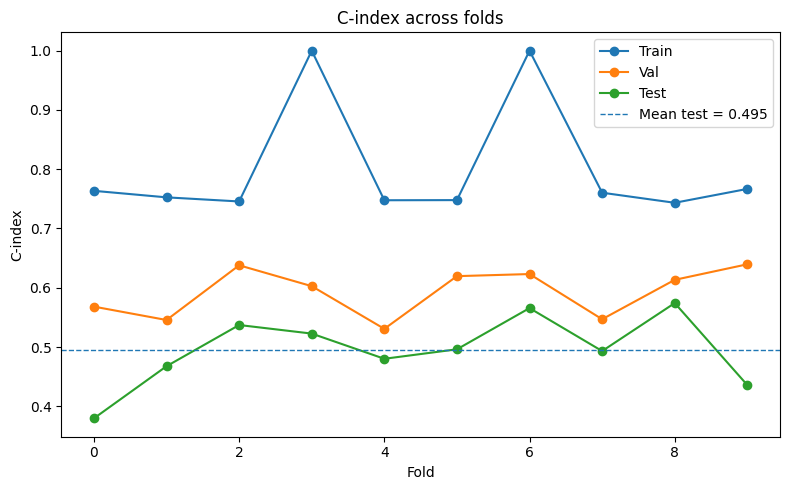

In [12]:

# ============================================================
# Plot: C-index by fold
# ============================================================

plt.figure(figsize=(8, 5))
x = fold_results["fold"].values

plt.plot(x, fold_results["cindex_train"], marker="o", label="Train")
plt.plot(x, fold_results["cindex_val"], marker="o", label="Val")
plt.plot(x, fold_results["cindex_test"], marker="o", label="Test")
plt.axhline(fold_results["cindex_test"].mean(), linestyle="--", linewidth=1, label=f"Mean test = {fold_results['cindex_test'].mean():.3f}")
plt.xlabel("Fold")
plt.ylabel("C-index")
plt.title("C-index across folds")
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR / "cindex_by_fold.png", dpi=200)
plt.show()

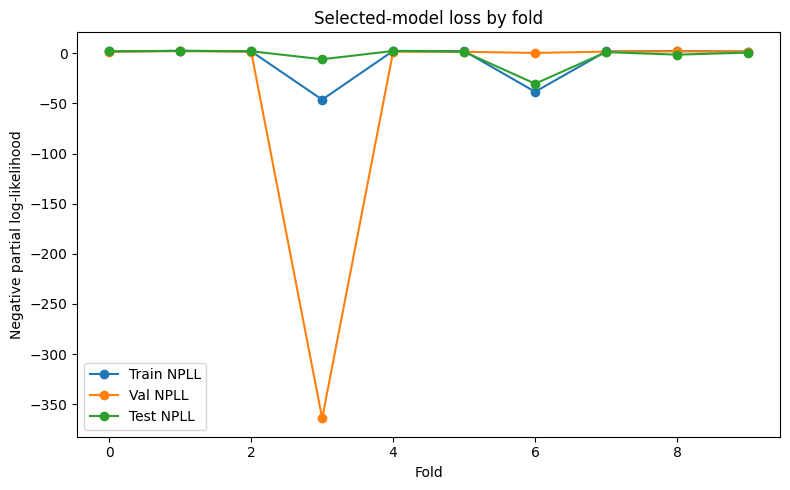

In [13]:

# ============================================================
# Plot: Partial log-likelihood loss by fold
# ============================================================

plt.figure(figsize=(8, 5))
x = fold_results["fold"].values

plt.plot(x, fold_results["npll_train"], marker="o", label="Train NPLL")
plt.plot(x, fold_results["npll_val"], marker="o", label="Val NPLL")
plt.plot(x, fold_results["npll_test"], marker="o", label="Test NPLL")
plt.xlabel("Fold")
plt.ylabel("Negative partial log-likelihood")
plt.title("Selected-model loss by fold")
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR / "npll_by_fold.png", dpi=200)
plt.show()

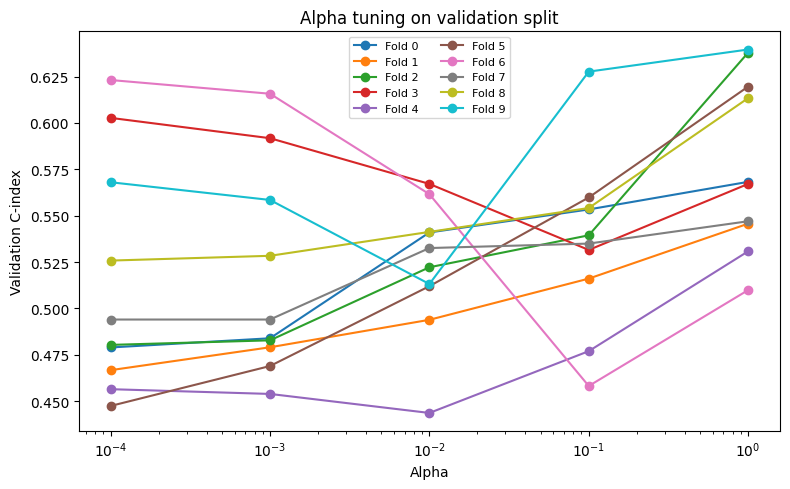

In [14]:

# ============================================================
# Plot: Alpha tuning curves on validation C-index
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

for fold_idx, sub in tuning_results.groupby("fold"):
    ax.plot(sub["alpha"].astype(float), sub["val_cindex"], marker="o", label=f"Fold {fold_idx}")



ax.set_xscale("log")
ax.set_xlabel("Alpha")
ax.set_ylabel("Validation C-index")
ax.set_title("Alpha tuning on validation split")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(OUTDIR / "alpha_tuning_val_cindex.png", dpi=200)
plt.show()

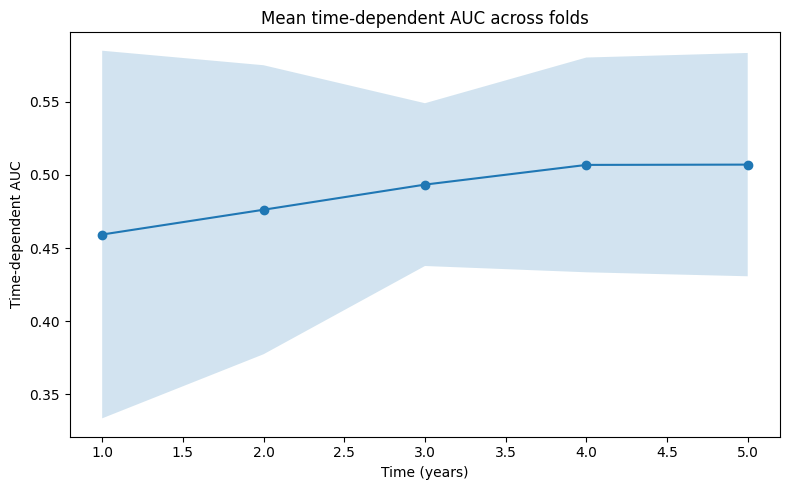

,time_years,auc,auc_std
0,1.0,0.459222,0.125598
1,2.0,0.476162,0.098743
2,3.0,0.493332,0.055617
3,4.0,0.506795,0.073374
4,5.0,0.506994,0.076293


In [15]:

# ============================================================
# Plot: Mean time-dependent AUC across folds
# ============================================================

auc_frames = []
for fold_idx in fold_results["fold"]:
    p = OUTDIR / f"fold_{fold_idx}_time_dependent_auc.csv"
    if p.exists():
        tmp = pd.read_csv(p)
        tmp["fold"] = fold_idx
        auc_frames.append(tmp)

if len(auc_frames) == 0:
    print("No AUC files found.")
else:
    auc_all = pd.concat(auc_frames, axis=0).reset_index(drop=True)

    mean_auc = auc_all.groupby("time_years", as_index=False)["auc"].mean()
    std_auc = auc_all.groupby("time_years", as_index=False)["auc"].std().rename(columns={"auc": "auc_std"})
    mean_auc = mean_auc.merge(std_auc, on="time_years", how="left")

    plt.figure(figsize=(8, 5))
    plt.plot(mean_auc["time_years"], mean_auc["auc"], marker="o")
    plt.fill_between(
        mean_auc["time_years"],
        mean_auc["auc"] - mean_auc["auc_std"].fillna(0),
        mean_auc["auc"] + mean_auc["auc_std"].fillna(0),
        alpha=0.2,
    )
    plt.xlabel("Time (years)")
    plt.ylabel("Time-dependent AUC")
    plt.title("Mean time-dependent AUC across folds")
    plt.tight_layout()
    plt.savefig(OUTDIR / "mean_time_dependent_auc.png", dpi=200)
    plt.show()

    display(mean_auc)
    mean_auc.to_csv(OUTDIR / "mean_time_dependent_auc.csv", index=False)

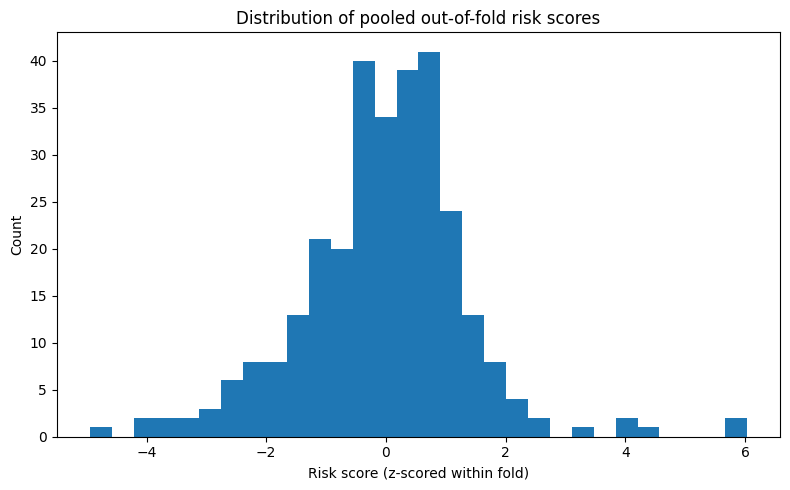

In [16]:

# ============================================================
# Plot: Risk score distribution (pooled OOF test predictions)
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(oof_test_df["risk_score_z"], bins=30)
plt.xlabel("Risk score (z-scored within fold)")
plt.ylabel("Count")
plt.title("Distribution of pooled out-of-fold risk scores")
plt.tight_layout()
plt.savefig(OUTDIR / "risk_score_distribution.png", dpi=200)
plt.show()

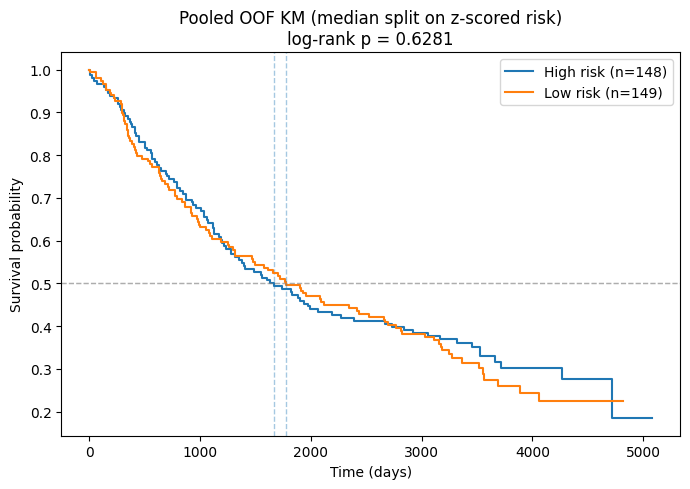

Pooled OOF log-rank p-value: 0.628148097501543


In [17]:

# ============================================================
# Kaplan-Meier on pooled out-of-fold test predictions
# ============================================================

pooled_df = oof_test_df.copy()

pooled_groups, pooled_info = assign_risk_groups(pooled_df["risk_score_z"].values, mode=RISK_GROUPING)
pooled_df["risk_group_pooled"] = pooled_groups

fig, ax = plt.subplots(figsize=(7, 5))
ax, pval = km_plot_with_pvalue(
    pooled_df.rename(columns={"risk_group_pooled": "risk_group_plot"}),
    risk_col="risk_group_plot",
    title=f"Pooled OOF KM ({RISK_GROUPING} split on z-scored risk)",
    show_median=True,
    ax=ax,
)
plt.tight_layout()
plt.savefig(OUTDIR / "km_pooled_oof.png", dpi=200)
plt.show()

print("Pooled OOF log-rank p-value:", pval)

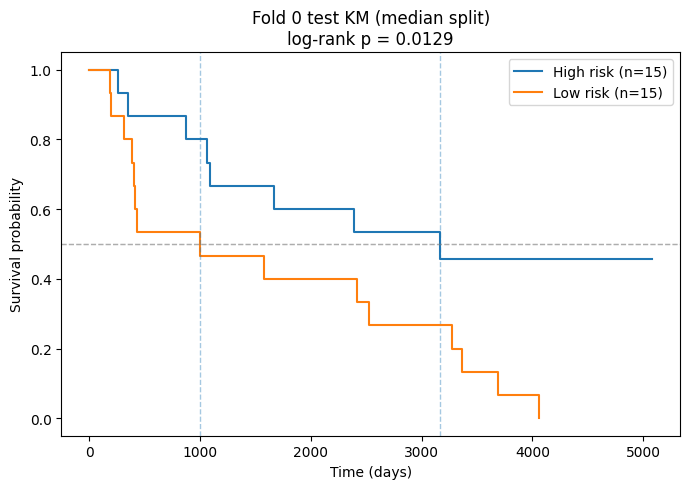

Fold log-rank p-value: 0.012904570100858706


In [18]:

# ============================================================
# Detailed KM plot for one selected fold
# ============================================================

sub = oof_test_df[oof_test_df["fold"] == SELECTED_FOLD_FOR_DETAILED_PLOTS].copy()

fig, ax = plt.subplots(figsize=(7, 5))
ax, pval = km_plot_with_pvalue(
    sub,
    risk_col="risk_group",
    title=f"Fold {SELECTED_FOLD_FOR_DETAILED_PLOTS} test KM ({RISK_GROUPING} split)",
    show_median=True,
    ax=ax,
)
plt.tight_layout()
plt.savefig(OUTDIR / f"km_fold_{SELECTED_FOLD_FOR_DETAILED_PLOTS}.png", dpi=200)
plt.show()

print("Fold log-rank p-value:", pval)

In [19]:

# ============================================================
# Save pooled OOF KM-ready table
# ============================================================

km_export = oof_test_df[[PATIENT_COL, TIME_COL, EVENT_COL, "fold", "risk_score_raw", "risk_score_z", "risk_group"]].copy()
km_export.to_csv(OUTDIR / "km_ready_oof_predictions.csv", index=False)
display(km_export.head())

,patient_id,time,event,fold,risk_score_raw,risk_score_z,risk_group
0,402,4656.0,0,0,0.257957,0.282297,High risk
1,410,4585.0,0,0,0.638163,0.698376,High risk
2,446,415.0,1,0,-0.421366,-0.461124,Low risk
3,449,3690.0,1,0,-0.814748,-0.891623,Low risk
4,450,385.0,1,0,-2.063326,-2.258008,Low risk


In [20]:

# ============================================================
# Risk score summary by fold
# ============================================================

risk_summary = oof_test_df.groupby("fold").agg(
    n_patients=(PATIENT_COL, "count"),
    mean_risk=("risk_score_z", "mean"),
    std_risk=("risk_score_z", "std"),
    event_rate=(EVENT_COL, "mean"),
).reset_index()

display(risk_summary)
risk_summary.to_csv(OUTDIR / "risk_score_summary_by_fold.csv", index=False)

,fold,n_patients,mean_risk,std_risk,event_rate
0,0,30,-0.084721,1.176582,0.766667
1,1,29,-0.323231,1.010931,0.655172
2,2,30,-0.122098,1.124358,0.666667
3,3,30,-0.204838,1.421466,0.800000
4,4,30,-0.176214,1.091049,0.666667
5,5,30,0.116251,1.105165,0.733333
6,6,30,0.209897,1.865044,0.733333
7,7,30,0.071244,1.338467,0.666667
8,8,29,0.162367,1.651046,0.655172
9,9,29,-0.005978,1.922415,0.620690


In [21]:

# ============================================================
# Top / bottom risk patients
# ============================================================

display(oof_test_df.sort_values("risk_score_z", ascending=False).head(10))
display(oof_test_df.sort_values("risk_score_z", ascending=True).head(10))

,patient_id,time,event,fold,risk_score_raw,risk_score_z,risk_group
276,535,4267.0,0,9,5.720498,6.036252,High risk
256,791,368.0,1,8,4.661650,5.754483,High risk
278,592,3802.0,0,9,4.225357,4.458583,High risk
205,855,1374.0,1,6,86.947990,3.939387,High risk
207,887,374.0,1,6,86.342954,3.911974,High risk
91,419,1976.0,1,3,79.057754,3.199490,High risk
231,787,2837.0,1,7,2.412918,2.492134,High risk
107,762,3111.0,0,3,59.079873,2.390980,High risk
187,626,1994.0,1,6,48.798748,2.210944,High risk
175,828,3656.0,0,5,1.838700,2.210543,High risk


,patient_id,time,event,fold,risk_score_raw,risk_score_z,risk_group
215,539,370.0,1,7,-4.791192,-4.948487,Low risk
203,823,3804.0,0,6,-91.917982,-4.164563,Low risk
94,468,4438.0,0,3,-98.391053,-3.981914,Low risk
25,800,2417.0,1,0,-3.420263,-3.742978,Low risk
239,407,2114.0,1,8,-2.895073,-3.573766,Low risk
287,772,340.0,1,9,-3.225774,-3.403827,Low risk
282,649,3466.0,0,9,-3.106012,-3.277454,Low risk
182,557,4014.0,0,6,-66.117860,-2.995627,Low risk
140,805,771.0,1,4,-2.272962,-2.838129,Low risk
195,718,3308.0,0,6,-60.870442,-2.757880,Low risk
